In [61]:
import numpy as np
import pandas as pd
import pynapple as nap
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from scipy.ndimage import gaussian_filter1d
from scipy.stats import pearsonr, spearmanr, mannwhitneyu
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

%load_ext autoreload
%autoreload 2

import sys
sys.path.insert(0, '/Users/harryclark/Documents/spatial-manifolds/src')
from spatial_manifolds.detect_grids import curate_clusters

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [62]:
source_path         = '/Users/harryclark/Downloads/COHORT12/'
CLASSIFICATIONS_CSV = '/Users/harryclark/Documents/spatial-manifolds/data/cell_classifications.csv'
OUTPUT_CSV          = 'vr_eta2_population.csv'
OVERWRITE           = False

mouse_days = {
    20: [14,15,16,17,18,19,20,21,22,23,24,25,26],
    21: [15,16,17,18,19,20,21,22,23,24,25,26],
    25: [16,17,18,19,20,21,22,23,24,25],
    26: [11,12,13,14,15,16,17,18,19],
    27: [16,17,18,19,20,21,22,23,24,26],
    28: [16,17,18,19,20,21,22,23,25],
    29: [16,17,18,19,20,21,22,23,25],
}

TRACK_LEN  = 200.0
N_BINS     = 100
SIGMA      = 2.5
MIN_TRIALS = 5

bin_edges   = np.linspace(0, TRACK_LEN, N_BINS + 1)
bin_centres = (bin_edges[:-1] + bin_edges[1:]) / 2.0

FEATURES = {
    'start_end': (bin_centres <  30) | (bin_centres >= 170),
    'outbound':  (bin_centres >= 30) & (bin_centres <  90),
    'reward':    (bin_centres >= 90) & (bin_centres < 110),
    'homebound': (bin_centres >= 110) & (bin_centres < 170),
}

FEATURE_COLOURS = {
    'start_end': '#7E57C2',
    'outbound':  '#26A69A',
    'reward':    '#EF5350',
    'homebound': '#42A5F5',
}

FEATURE_LABELS = {
    'start_end': 'Start / End  (0–30 & 170–200 cm)',
    'outbound':  'Outbound  (30–90 cm)',
    'reward':    'Reward zone  (90–110 cm)',
    'homebound': 'Homebound  (110–170 cm)',
}

REGION_SPANS = [
    ('start_end',  0,   30),
    ('outbound',  30,   90),
    ('reward',    90,  110),
    ('homebound',110,  170),
    ('start_end',170,  200),
]

feat_names = list(FEATURES.keys())

# Sanity-check config
SANITY_MOUSE   = 29
SANITY_DAY     = 23
N_SHOW         = 5
N_SHUFFLES     = 500
N_SHUFFLES_POP = 200
ML_BINS        = 10

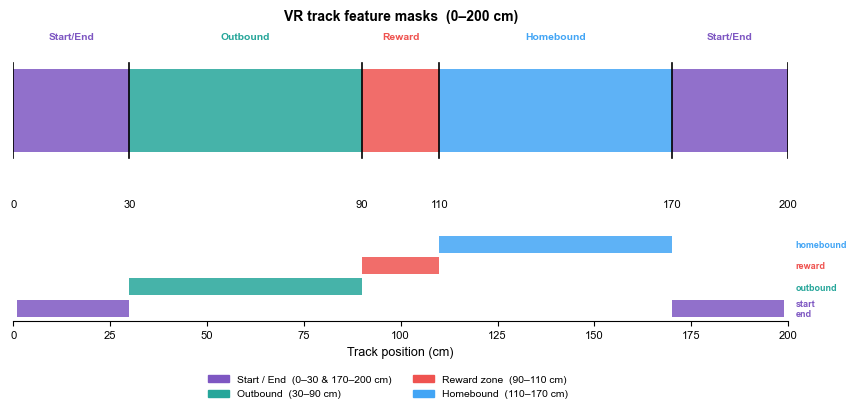

In [63]:
fig, axes = plt.subplots(2, 1, figsize=(10, 3.5),
                         gridspec_kw=dict(hspace=0.60, height_ratios=[1, 0.75]))

ax_t = axes[0]
for feat, x0, x1 in REGION_SPANS:
    ax_t.axvspan(x0, x1, ymin=0.15, ymax=0.85,
                 color=FEATURE_COLOURS[feat], alpha=0.85, lw=0)
for x in [0, 30, 90, 110, 170, 200]:
    ax_t.axvline(x, ymin=0.10, ymax=0.90, color='k', lw=1.2)
    ax_t.text(x, -0.25, str(x), ha='center', va='top', fontsize=8,
              transform=ax_t.get_xaxis_transform())
for xp, txt, feat in zip([15, 60, 100, 140, 185],
                          ['Start/End', 'Outbound', 'Reward', 'Homebound', 'Start/End'],
                          ['start_end','outbound','reward','homebound','start_end']):
    ax_t.text(xp, 1.08, txt, ha='center', va='bottom', fontsize=7.5,
              fontweight='bold', color=FEATURE_COLOURS[feat],
              transform=ax_t.get_xaxis_transform())
ax_t.set_xlim(0, 200); ax_t.set_ylim(0, 1); ax_t.axis('off')
ax_t.set_title('VR track feature masks  (0–200 cm)', fontsize=10, fontweight='bold', pad=22)

ax_m = axes[1]
for fi, (fname, fmask) in enumerate(FEATURES.items()):
    y = fi * 1.25
    ax_m.fill_between(bin_centres, y, y + fmask.astype(float),
                      color=FEATURE_COLOURS[fname], alpha=0.85, lw=0, step='mid')
    ax_m.text(202, y + 0.45, fname.replace('_','\n'),
              fontsize=6.5, va='center', color=FEATURE_COLOURS[fname], fontweight='bold')
ax_m.set_xlim(0, 200); ax_m.set_yticks([])
ax_m.set_xlabel('Track position (cm)', fontsize=9)
ax_m.spines[['top','right','left']].set_visible(False)
ax_m.tick_params(labelsize=8)

legend_patches = [mpatches.Patch(color=FEATURE_COLOURS[f], label=FEATURE_LABELS[f])
                  for f in FEATURES]
fig.legend(handles=legend_patches, loc='lower center', ncol=2, fontsize=7.5,
           frameon=False, bbox_to_anchor=(0.5, -0.14))
plt.savefig('track_feature_diagram.pdf', bbox_inches='tight', dpi=150)
plt.show()

In [64]:
def load_vr_session(mouse, day, source_path):
    sf = f'{source_path}M{mouse}/D{day:02}/VR/'
    beh      = nap.load_file(sf + f'sub-{mouse}_day-{day:02}_ses-VR_beh.nwb')
    clusters = curate_clusters(
        nap.load_file(sf + f'sub-{mouse}_day-{day:02}_ses-VR_srt-kilosort4_clusters.npz')
    )
    return beh, clusters


def get_beaconed_hit_epoch(beh):
    trials = beh['trials']
    return trials[(trials.type == 'b') & (trials.performance == 'hit')]


def compute_avg_firing_profile(cluster_ts, position, ep_b_hit,
                                n_bins=N_BINS, track_len=TRACK_LEN, sigma=SIGMA):
    tc = nap.compute_1d_tuning_curves(
        nap.TsGroup([cluster_ts]), position,
        nb_bins=n_bins, minmax=[0.0, track_len], ep=ep_b_hit,
    )[0]
    return gaussian_filter1d(np.nan_to_num(np.array(tc, dtype=float)), sigma=sigma)


def correlate_with_features(profile, features):
    return {fname: float(pearsonr(profile, fmask.astype(float))[0])
            for fname, fmask in features.items()}


def eta_squared(profile, features):
    """Fraction of spatial variance explained by feature-group membership."""
    grand_mean = profile.mean()
    ss_total   = np.sum((profile - grand_mean) ** 2)
    if ss_total == 0:
        return np.nan
    ss_between = sum(
        np.sum(mask) * (profile[mask].mean() - grand_mean) ** 2
        for mask in features.values()
    )
    return float(ss_between / ss_total)


def eta2_shuffle_null(profile, features, n_shuffles=500, rng=None):
    """Circular-shift null: preserves spatial autocorrelation, randomises
    alignment to feature boundaries."""
    if rng is None:
        rng = np.random.default_rng()
    shifts = rng.integers(1, len(profile), size=n_shuffles)
    return np.array([eta_squared(np.roll(profile, s), features) for s in shifts])


def run_session(mouse, day, source_path, n_shuffles=N_SHUFFLES, rng=None):
    """Load one VR session; return (rows, profiles).
    Each row contains Pearson r per feature, eta2, eta2_sig, eta2_pval.
    profiles is {cluster_id: smoothed_rate_map}.
    """
    beh, clusters = load_vr_session(mouse, day, source_path)
    ep_b_hit = get_beaconed_hit_epoch(beh)
    if len(ep_b_hit) < MIN_TRIALS:
        print(f'  M{mouse} D{day:02}: {len(ep_b_hit)} beaconed-hit trials — skipping')
        return [], {}
    if rng is None:
        rng = np.random.default_rng()

    position = beh['P']
    rows, profiles = [], {}
    for cid in clusters.index:
        prof = compute_avg_firing_profile(clusters[cid], position, ep_b_hit)
        profiles[cid] = prof

        null      = eta2_shuffle_null(prof, FEATURES, n_shuffles=n_shuffles, rng=rng)
        eta2_real = eta_squared(prof, FEATURES)
        thresh_95 = float(np.nanpercentile(null, 95))
        p_val     = (np.sum(null >= eta2_real) + 1) / (n_shuffles + 1)

        row = dict(
            mouse                 = int(mouse),
            day                   = int(day),
            cluster_id            = int(cid),
            brain_region          = str(clusters.brain_region[cid]),
            n_beaconed_hit_trials = int(len(ep_b_hit)),
            eta2                  = float(eta2_real),
            eta2_null_95          = thresh_95,
            eta2_pval             = float(p_val),
            eta2_sig              = bool(np.isfinite(eta2_real) and eta2_real > thresh_95),
        )
        row.update(correlate_with_features(prof, FEATURES))
        rows.append(row)
    return rows, profiles

---
## Sanity check — M29 D23

Run one session before the full cohort. Confirm that:
- Feature correlations reflect genuine spatial tuning structure
- η²-significant cells have firing organised by feature boundaries
- Medial-lateral position shows the expected gradient

In [65]:
print(f'Running M{SANITY_MOUSE} D{SANITY_DAY} ...')
rows_s, profiles_s = run_session(SANITY_MOUSE, SANITY_DAY, source_path,
                                  n_shuffles=N_SHUFFLES, rng=np.random.default_rng(42))
df_s = pd.DataFrame(rows_s)

print(f'  {len(df_s)} cells,  {df_s["n_beaconed_hit_trials"].iloc[0]} beaconed-hit trials')
print(f'  Feature-sensitive (η² p<0.05): {df_s["eta2_sig"].sum()} / {len(df_s)}')
print(f'  η² range: {df_s["eta2"].min():.3f} – {df_s["eta2"].max():.3f}')
print('\nTop 8 by reward-zone correlation:')
print(df_s.nlargest(8, 'reward')[
    ['cluster_id','brain_region','eta2','eta2_pval'] + feat_names
].to_string(index=False))

Running M29 D23 ...
  211 cells,  65 beaconed-hit trials
  Feature-sensitive (η² p<0.05): 10 / 211
  η² range: 0.023 – 0.845

Top 8 by reward-zone correlation:
 cluster_id brain_region     eta2  eta2_pval  start_end  outbound   reward  homebound
        215        ENTm3 0.667873   0.015968  -0.214040 -0.157275 0.816400  -0.163145
        220        ENTm3 0.610816   0.373253  -0.394626  0.160906 0.705021  -0.227825
        297        ENTm3 0.609308   0.025948   0.302764 -0.249652 0.625235  -0.462425
        270        ENTm2 0.404356   0.093812  -0.285648 -0.256319 0.557018   0.177313
        196        ENTm3 0.324715   0.181637  -0.237441 -0.120824 0.552793  -0.003623
        156        ENTm2 0.581670   0.047904  -0.387941 -0.367979 0.549348   0.396288
         28          PAR 0.326273   0.576846  -0.032719 -0.047414 0.547466  -0.278268
        267        ENTm2 0.397083   0.035928   0.054073  0.102179 0.499280  -0.483108


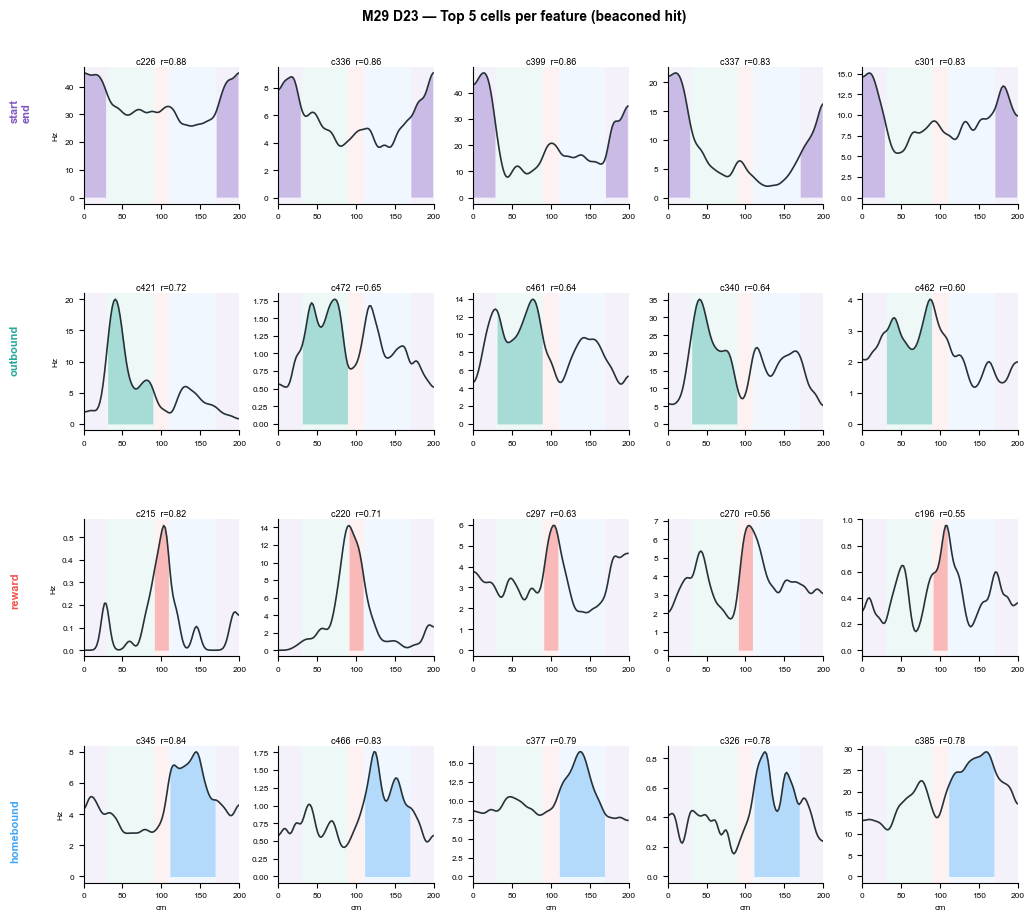

In [66]:
# Top N cells per feature — rate maps with feature region highlighted
fig = plt.figure(figsize=(N_SHOW * 2.1, len(feat_names) * 2.4))
gs  = gridspec.GridSpec(len(feat_names), N_SHOW, figure=fig,
                        hspace=0.65, wspace=0.25,
                        left=0.08, right=0.97, top=0.92, bottom=0.07)

for fi, fname in enumerate(feat_names):
    top_ids = df_s.nlargest(N_SHOW, fname)['cluster_id'].values
    for ci, cid in enumerate(top_ids):
        ax  = fig.add_subplot(gs[fi, ci])
        prof = profiles_s[cid]
        r   = df_s.loc[df_s['cluster_id'] == cid, fname].iloc[0]
        for feat, x0, x1 in REGION_SPANS:
            ax.axvspan(x0, x1, alpha=0.08, color=FEATURE_COLOURS[feat], lw=0)
        ax.fill_between(bin_centres, prof,
                        where=FEATURES[fname], alpha=0.35,
                        color=FEATURE_COLOURS[fname], lw=0)
        ax.plot(bin_centres, prof, color='#263238', lw=1.2)
        ax.set_xlim(0, 200)
        ax.set_title(f'c{cid}  r={r:.2f}', fontsize=6.5, pad=2)
        ax.spines[['top','right']].set_visible(False)
        ax.tick_params(labelsize=6)
        if ci == 0: ax.set_ylabel('Hz', fontsize=6)
        if fi == len(feat_names)-1: ax.set_xlabel('cm', fontsize=6)
    fig.text(0.01, 1-(fi+0.5)/len(feat_names), fname.replace('_','\n'),
             ha='left', va='center', fontsize=8, fontweight='bold',
             color=FEATURE_COLOURS[fname], rotation=90)

fig.suptitle(f'M{SANITY_MOUSE} D{SANITY_DAY} — Top {N_SHOW} cells per feature (beaconed hit)',
             fontsize=10, fontweight='bold')
plt.savefig(f'sanity_M{SANITY_MOUSE}D{SANITY_DAY}_feature_top_cells.pdf',
            bbox_inches='tight', dpi=150)
plt.show()

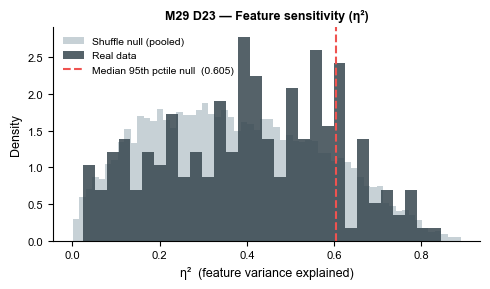

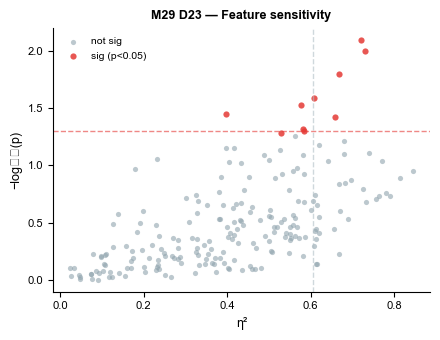

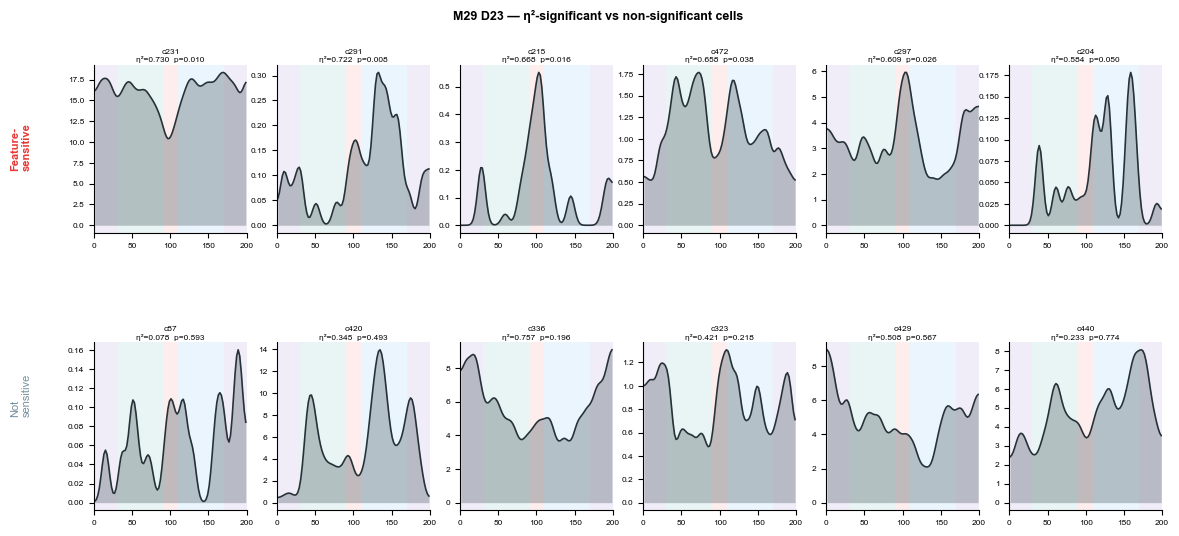

In [67]:
# Rebuild pooled null from individual shuffle runs
# (re-run shuffles here for plotting; fast since it's just np.roll)
_rng = np.random.default_rng(42)
_null_store = []
for prof in profiles_s.values():
    _null_store.append(eta2_shuffle_null(prof, FEATURES, n_shuffles=N_SHUFFLES, rng=_rng))
pooled_null   = np.concatenate(_null_store)
median_thresh = df_s['eta2_null_95'].median()

# ── Plot A: η² distribution real vs null ──────────────────────────────────────
fig1, ax = plt.subplots(figsize=(5, 3))
ax.hist(pooled_null, bins=60, color='#B0BEC5', edgecolor='none',
        alpha=0.7, density=True, label='Shuffle null (pooled)')
ax.hist(df_s['eta2'].dropna(), bins=30, color='#37474F', edgecolor='none',
        alpha=0.85, density=True, label='Real data')
ax.axvline(median_thresh, color='#EF5350', lw=1.5, ls='--',
           label=f'Median 95th pctile null  ({median_thresh:.3f})')
ax.set_xlabel('η²  (feature variance explained)', fontsize=9)
ax.set_ylabel('Density', fontsize=9)
ax.set_title(f'M{SANITY_MOUSE} D{SANITY_DAY} — Feature sensitivity (η²)', fontsize=9, fontweight='bold')
ax.legend(fontsize=7.5, frameon=False)
ax.spines[['top','right']].set_visible(False)
ax.tick_params(labelsize=8)
plt.tight_layout()
plt.savefig(f'sanity_M{SANITY_MOUSE}D{SANITY_DAY}_eta2_distribution.pdf', bbox_inches='tight', dpi=150)
plt.show()

# ── Plot B: volcano (η² vs −log10 p) ─────────────────────────────────────────
sig_mask = df_s['eta2_sig']
fig2, ax2 = plt.subplots(figsize=(4.5, 3.5))
ax2.scatter(df_s.loc[~sig_mask,'eta2'], -np.log10(df_s.loc[~sig_mask,'eta2_pval']),
            s=14, color='#90A4AE', alpha=0.6, lw=0, label='not sig')
ax2.scatter(df_s.loc[ sig_mask,'eta2'], -np.log10(df_s.loc[ sig_mask,'eta2_pval']),
            s=20, color='#E53935', alpha=0.85, lw=0, label='sig (p<0.05)')
ax2.axhline(-np.log10(0.05), color='#E53935', lw=1, ls='--', alpha=0.6)
ax2.axvline(median_thresh,   color='#B0BEC5', lw=1, ls='--', alpha=0.6)
ax2.set_xlabel('η²', fontsize=9)
ax2.set_ylabel('−log₁₀(p)', fontsize=9)
ax2.set_title(f'M{SANITY_MOUSE} D{SANITY_DAY} — Feature sensitivity', fontsize=9, fontweight='bold')
ax2.legend(fontsize=7.5, frameon=False)
ax2.spines[['top','right']].set_visible(False)
ax2.tick_params(labelsize=8)
plt.tight_layout()
plt.show()

# ── Plot C: rate maps — top sig cells vs random non-sig ──────────────────────
sig_ids  = df_s[df_s['eta2_sig']].nlargest(N_SHOW+1, 'eta2')['cluster_id'].values
nsig_ids = df_s[~df_s['eta2_sig']].sample(min(N_SHOW+1, (~df_s['eta2_sig']).sum()),
                                            random_state=0)['cluster_id'].values
n_cols = max(len(sig_ids), len(nsig_ids), 1)
fig3   = plt.figure(figsize=(n_cols * 2.0, 5.5))
gs3    = gridspec.GridSpec(2, n_cols, figure=fig3, hspace=0.65, wspace=0.20,
                           left=0.08, right=0.97, top=0.88, bottom=0.07)

def _plot_profile(ax, cid):
    prof = profiles_s[cid]
    row  = df_s[df_s['cluster_id'] == cid].iloc[0]
    for feat, x0, x1 in REGION_SPANS:
        ax.axvspan(x0, x1, alpha=0.10, color=FEATURE_COLOURS[feat], lw=0)
    ax.fill_between(bin_centres, prof, alpha=0.30, color='#37474F', lw=0)
    ax.plot(bin_centres, prof, color='#263238', lw=1.2)
    ax.set_xlim(0, 200)
    ax.set_title(f'c{cid}\nη²={row["eta2"]:.3f}  p={row["eta2_pval"]:.3f}', fontsize=6.0, pad=2)
    ax.spines[['top','right']].set_visible(False)
    ax.tick_params(labelsize=6)

for ci, cid in enumerate(sig_ids):  fig3.add_subplot(gs3[0, ci]); _plot_profile(plt.gca(), cid)
for ci, cid in enumerate(nsig_ids): fig3.add_subplot(gs3[1, ci]); _plot_profile(plt.gca(), cid)
fig3.text(0.01, 0.73, 'Feature-\nsensitive', va='center', ha='left',
          fontsize=8, fontweight='bold', color='#E53935', rotation=90)
fig3.text(0.01, 0.28, 'Not\nsensitive', va='center', ha='left',
          fontsize=8, color='#78909C', rotation=90)
fig3.suptitle(f'M{SANITY_MOUSE} D{SANITY_DAY} — η²-significant vs non-significant cells',
              fontsize=9, fontweight='bold')
plt.savefig(f'sanity_M{SANITY_MOUSE}D{SANITY_DAY}_eta2_rate_maps.pdf', bbox_inches='tight', dpi=150)
plt.show()

Matched 160 / 211 cells
Spearman r(ML, η²): ρ=-0.011  p=0.8895
Mann-Whitney ML (sig vs not-sig): p=0.8051
  Median ML  sig: 3510 µm   !sig: 3510 µm


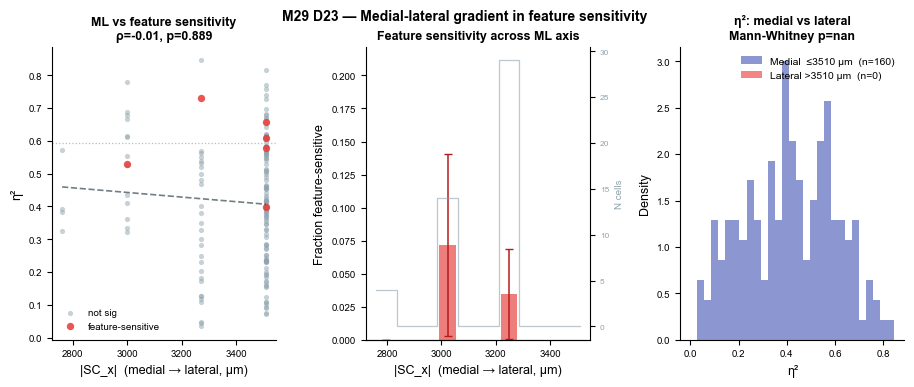

In [68]:
# Merge M29D23 η² results with cell_classifications.csv for ML position
df_class = pd.read_csv(CLASSIFICATIONS_CSV)
df_class = df_class[(df_class['mouse'] == SANITY_MOUSE) &
                     (df_class['day']   == SANITY_DAY)].copy()
df_class['ml'] = df_class['SC_x'].abs()

df_ml = df_s.merge(df_class[['cluster_id','ml','SC_x','cell_type']], on='cluster_id', how='inner')
print(f'Matched {len(df_ml)} / {len(df_s)} cells')

sig_ml  = df_ml[df_ml['eta2_sig']]
nsig_ml = df_ml[~df_ml['eta2_sig']]
rho, rho_p   = spearmanr(df_ml['ml'], df_ml['eta2'])
mwu_u, mwu_p = mannwhitneyu(sig_ml['ml'], nsig_ml['ml'], alternative='two-sided')
print(f'Spearman r(ML, η²): ρ={rho:.3f}  p={rho_p:.4f}')
print(f'Mann-Whitney ML (sig vs not-sig): p={mwu_p:.4f}')
print(f'  Median ML  sig: {sig_ml["ml"].median():.0f} µm   !sig: {nsig_ml["ml"].median():.0f} µm')

ml_median   = df_ml['ml'].median()
medial_eta  = df_ml[df_ml['ml'] <= ml_median]['eta2'].dropna()
lateral_eta = df_ml[df_ml['ml'] >  ml_median]['eta2'].dropna()
_, mwu2_p   = mannwhitneyu(medial_eta, lateral_eta, alternative='two-sided')

fig, axes = plt.subplots(1, 3, figsize=(11, 3.8), gridspec_kw=dict(wspace=0.40))

# A: scatter ML vs η²
ax = axes[0]
ax.scatter(nsig_ml['ml'], nsig_ml['eta2'], s=14, color='#90A4AE', alpha=0.5, lw=0, label='not sig')
ax.scatter(sig_ml['ml'],  sig_ml['eta2'],  s=28, color='#E53935', alpha=0.85, lw=0, label='feature-sensitive')
ml_s = np.sort(df_ml['ml'].values)
ax.plot(ml_s, np.polyval(np.polyfit(df_ml['ml'], df_ml['eta2'], 1), ml_s),
        color='#37474F', lw=1.2, ls='--', alpha=0.7)
ax.axhline(df_ml['eta2_null_95'].mean(), color='#B0BEC5', lw=0.9, ls=':')
ax.set_xlabel('|SC_x|  (medial → lateral, µm)', fontsize=9)
ax.set_ylabel('η²', fontsize=9)
ax.set_title(f'ML vs feature sensitivity\nρ={rho:.2f}, p={rho_p:.3f}', fontsize=9, fontweight='bold')
ax.legend(fontsize=7, frameon=False)
ax.spines[['top','right']].set_visible(False); ax.tick_params(labelsize=7)

# B: fraction sig per ML bin
ax = axes[1]
ml_vals = df_ml['ml'].values
edges   = np.linspace(ml_vals.min(), ml_vals.max(), ML_BINS+1)
ctrs    = (edges[:-1]+edges[1:])/2
n_all   = np.array([np.sum((ml_vals>=e0)&(ml_vals<e1)) for e0,e1 in zip(edges[:-1],edges[1:])])
n_sig_b = np.array([np.sum((sig_ml['ml'].values>=e0)&(sig_ml['ml'].values<e1))
                    for e0,e1 in zip(edges[:-1],edges[1:])])
frac = np.where(n_all>0, n_sig_b/n_all, np.nan)
sem  = np.where(n_all>0, np.sqrt(frac*(1-frac)/np.where(n_all>0,n_all,1)), np.nan)
ax.bar(ctrs, frac, width=np.diff(edges)*0.8, color='#E53935', alpha=0.65, lw=0)
ax.errorbar(ctrs, frac, yerr=sem, fmt='none', color='#B71C1C', lw=1.1, capsize=3)
ax2b = ax.twinx()
ax2b.step(edges, np.append(n_all,n_all[-1]), color='#90A4AE', lw=0.9, where='post', alpha=0.6)
ax2b.set_ylabel('N cells', fontsize=7, color='#90A4AE')
ax2b.tick_params(labelsize=6, labelcolor='#90A4AE')
ax2b.spines[['top','left']].set_visible(False)
ax.set_xlabel('|SC_x|  (medial → lateral, µm)', fontsize=9)
ax.set_ylabel('Fraction feature-sensitive', fontsize=9)
ax.set_title('Feature sensitivity across ML axis', fontsize=9, fontweight='bold')
ax.set_ylim(0, min(1.05, np.nanmax(frac)+0.15))
ax.spines[['top','right']].set_visible(False); ax.tick_params(labelsize=7)

# C: η² distribution medial vs lateral
ax = axes[2]
bins_e = np.linspace(0, df_ml['eta2'].max(), 30)
ax.hist(medial_eta,  bins=bins_e, color='#5C6BC0', alpha=0.70, density=True, edgecolor='none',
        label=f'Medial  ≤{ml_median:.0f} µm  (n={len(medial_eta)})')
ax.hist(lateral_eta, bins=bins_e, color='#EF5350', alpha=0.70, density=True, edgecolor='none',
        label=f'Lateral >{ml_median:.0f} µm  (n={len(lateral_eta)})')
ax.set_xlabel('η²', fontsize=9)
ax.set_ylabel('Density', fontsize=9)
ax.set_title(f'η²: medial vs lateral\nMann-Whitney p={mwu2_p:.3f}', fontsize=9, fontweight='bold')
ax.legend(fontsize=7.5, frameon=False)
ax.spines[['top','right']].set_visible(False); ax.tick_params(labelsize=7)

fig.suptitle(f'M{SANITY_MOUSE} D{SANITY_DAY} — Medial-lateral gradient in feature sensitivity',
             fontsize=10, fontweight='bold')
plt.savefig(f'sanity_M{SANITY_MOUSE}D{SANITY_DAY}_eta2_medial_lateral.pdf', bbox_inches='tight', dpi=150)
plt.show()

---
## Full cohort

Loops all sessions in `mouse_days`, computes firing profiles + feature correlations + η²
in one pass. Saves to `vr_eta2_population.csv`. Set `OVERWRITE = True` in `cell-config`
to force a rerun.

In [69]:
if Path(OUTPUT_CSV).exists() and not OVERWRITE:
    df_pop = pd.read_csv(OUTPUT_CSV)
    print(f'Loaded {OUTPUT_CSV}: {len(df_pop)} cells, '
          f'{df_pop[["mouse","day"]].drop_duplicates().shape[0]} sessions')
else:
    all_rows = []
    RNG_POP  = np.random.default_rng(0)
    for mouse, days in mouse_days.items():
        for day in days:
            if not (Path(source_path)/f'M{mouse}'/f'D{day:02}'/'VR').exists():
                continue
            print(f'M{mouse} D{day:02} ...', end=' ', flush=True)
            try:
                rows, _ = run_session(mouse, day, source_path,
                                       n_shuffles=N_SHUFFLES_POP, rng=RNG_POP)
                all_rows.extend(rows)
                print(f'{len(rows)} cells')
            except Exception as e:
                print(f'ERROR: {e}')
    df_pop = pd.DataFrame(all_rows)
    df_pop.to_csv(OUTPUT_CSV, index=False)
    print(f'\nSaved {OUTPUT_CSV}: {len(df_pop)} cells, '
          f'{df_pop[["mouse","day"]].drop_duplicates().shape[0]} sessions')

print(f'\nOverall feature-sensitive: {df_pop["eta2_sig"].sum()} / {len(df_pop)} '
      f'({100*df_pop["eta2_sig"].mean():.1f}%)')
df_pop.head()

M20 D14 ... 204 cells
M20 D15 ... 75 cells
M20 D16 ... 219 cells
M20 D17 ... 132 cells
M20 D18 ... 151 cells
M20 D19 ... 118 cells
M20 D20 ... 103 cells
M20 D21 ... 117 cells
M20 D22 ... 81 cells
M20 D23 ... 85 cells
M20 D24 ... 81 cells
M20 D25 ... 37 cells
M20 D26 ... 154 cells
M21 D15 ... 268 cells
M21 D16 ... 242 cells
M21 D17 ... 312 cells
M21 D18 ... 219 cells
M21 D19 ... 421 cells
M21 D20 ... 331 cells
M21 D21 ... 340 cells
M21 D22 ... 164 cells
M21 D23 ... 350 cells
M21 D24 ... 229 cells
M21 D25 ... 184 cells
M21 D26 ... 209 cells
M25 D16 ... 72 cells
M25 D17 ... 68 cells
M25 D18 ... 146 cells
M25 D19 ... 61 cells
M25 D20 ... 68 cells
M25 D21 ...   M25 D21: 0 beaconed-hit trials — skipping
0 cells
M25 D22 ... 189 cells
M25 D23 ... 229 cells
M25 D24 ... 69 cells
M25 D25 ... 152 cells
M26 D11 ... 165 cells
M26 D12 ... 156 cells
M26 D13 ... 118 cells
M26 D14 ... 29 cells
M26 D15 ... 141 cells
M26 D16 ... 48 cells
M26 D17 ... 57 cells
M26 D18 ... 103 cells
M26 D19 ... 346 cells
M27

,mouse,day,cluster_id,brain_region,n_beaconed_hit_trials,eta2,eta2_null_95,eta2_pval,eta2_sig,start_end,outbound,reward,homebound
0,20,14,34,ENTm1,91,0.826366,0.821338,0.039801,True,-0.532375,0.604493,0.527325,-0.417333
1,20,14,37,ENTm1,91,0.501787,0.826711,0.915423,False,0.522777,-0.385209,-0.457374,0.161853
2,20,14,57,ENTm1,91,0.447257,0.656723,0.557214,False,0.531585,-0.591382,0.070784,0.013458
3,20,14,80,ENTm1,91,0.410163,0.664584,0.447761,False,-0.279581,-0.337702,0.486680,0.298676
4,20,14,85,ENTm1,91,0.666852,0.785221,0.293532,False,-0.424946,0.374265,0.625604,-0.358873


MEC principal cells (ENTm*, FR<10Hz): 5341
cell_type
NG       3970
Other     891
GC        480

── All MEC principal  (n=5341, sig=520) ──
  Spearman r(ML,η²): ρ=-0.009  p=0.5303
  MW η² med vs lat:  p=0.1800
  Best feature counts:
best_feature
reward       202
start_end    118
homebound    107
outbound      93


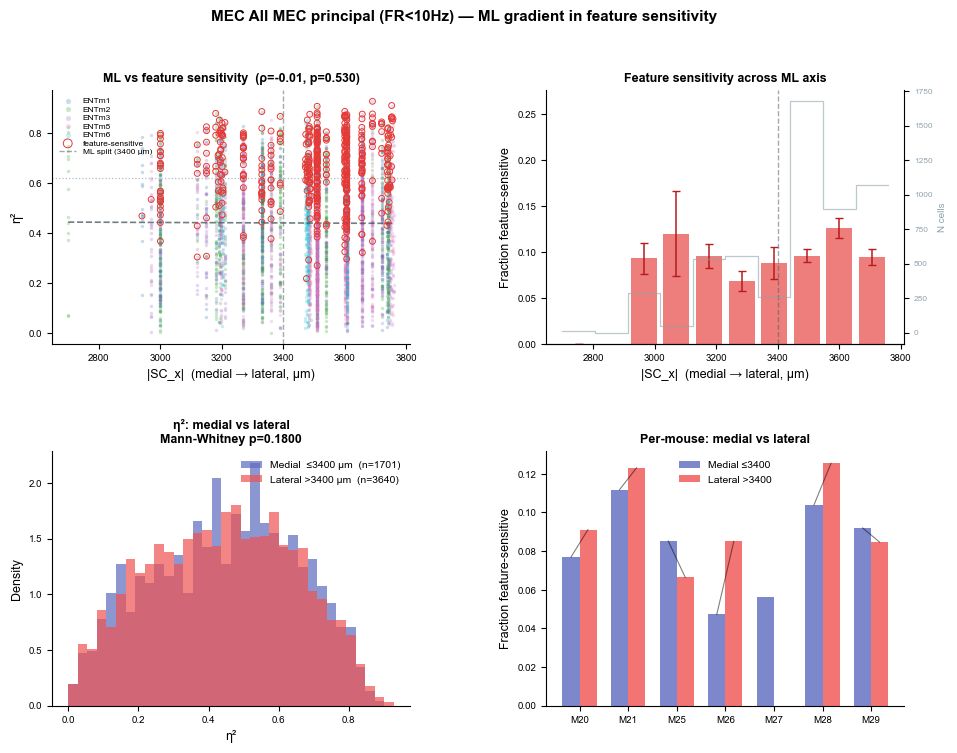

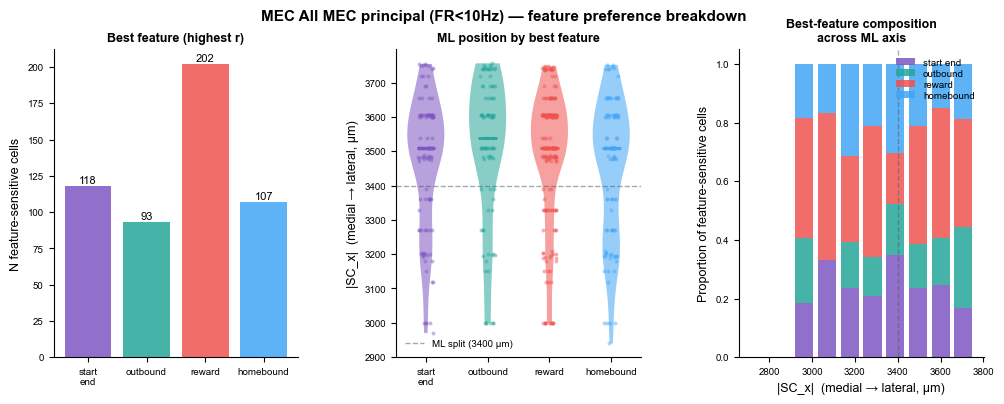


── Grid cells (GC)  (n=480, sig=39) ──
  Spearman r(ML,η²): ρ=0.051  p=0.2656
  MW η² med vs lat:  p=0.6372
  Best feature counts:
best_feature
homebound    13
start_end    10
outbound      8
reward        8


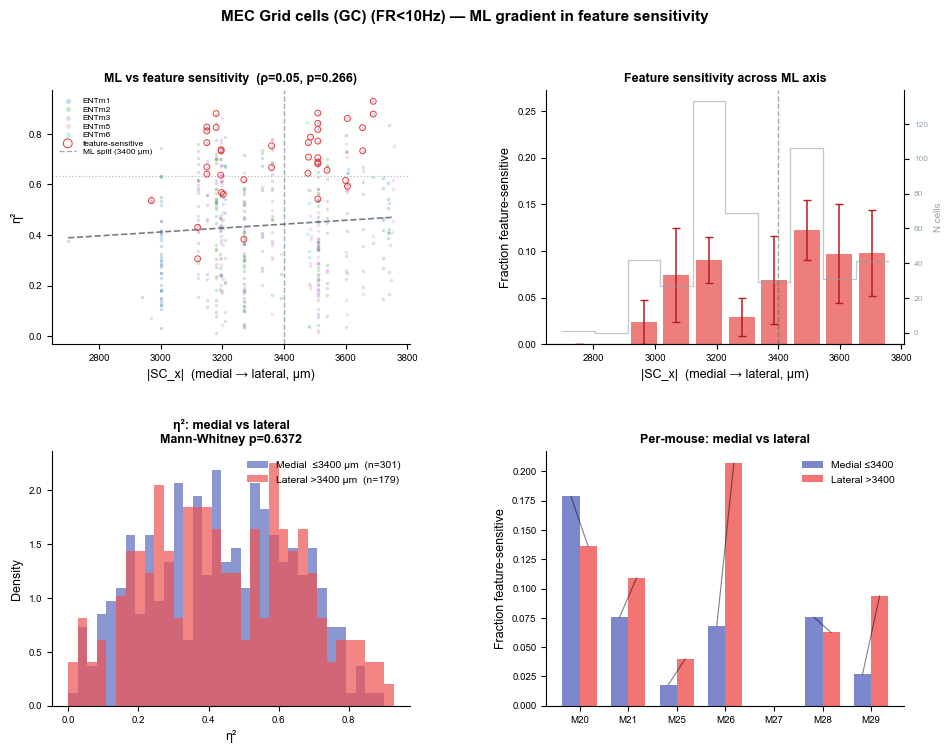

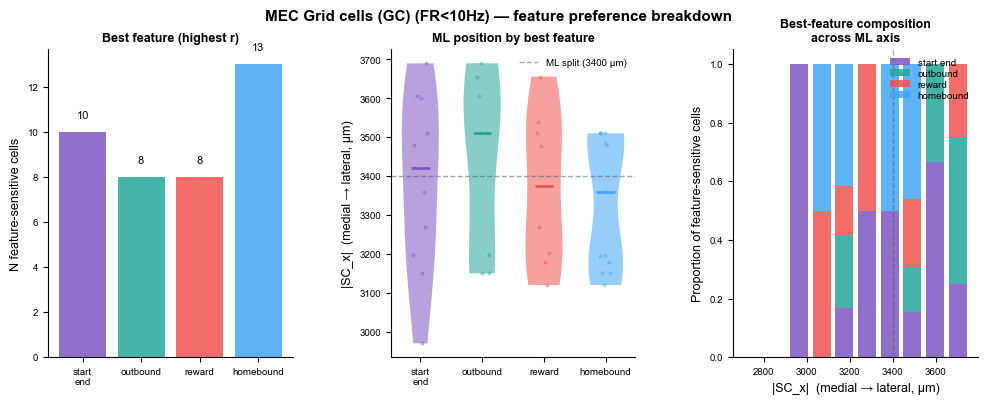


── Non-grid spatial  (n=3970, sig=408) ──
  Spearman r(ML,η²): ρ=-0.014  p=0.3873
  MW η² med vs lat:  p=0.1173
  Best feature counts:
best_feature
reward       167
start_end     91
homebound     77
outbound      73


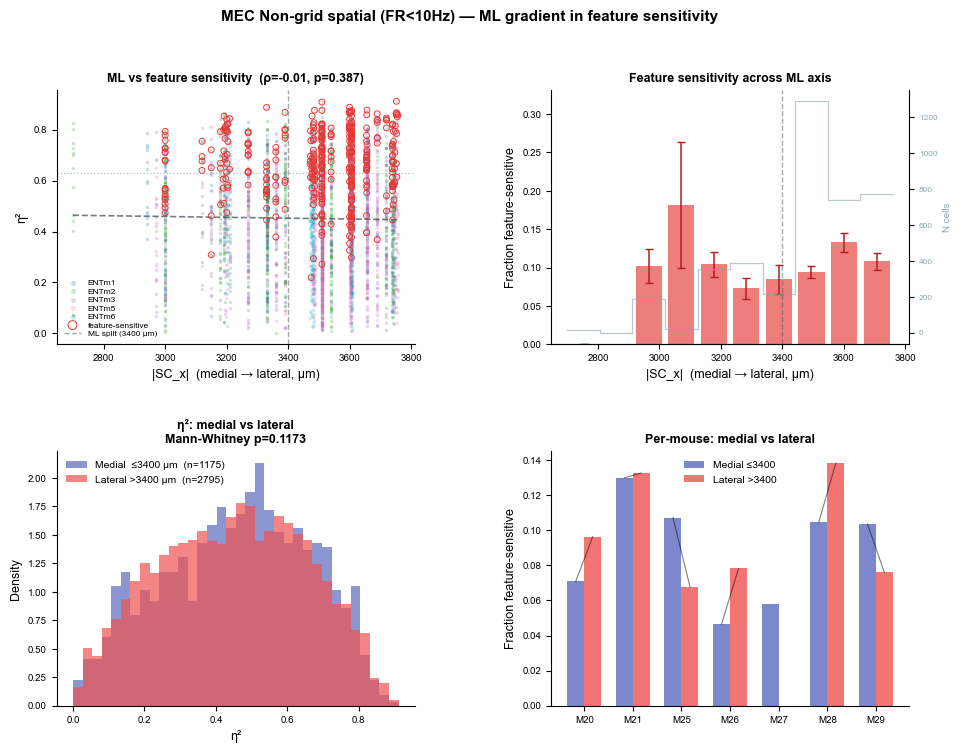

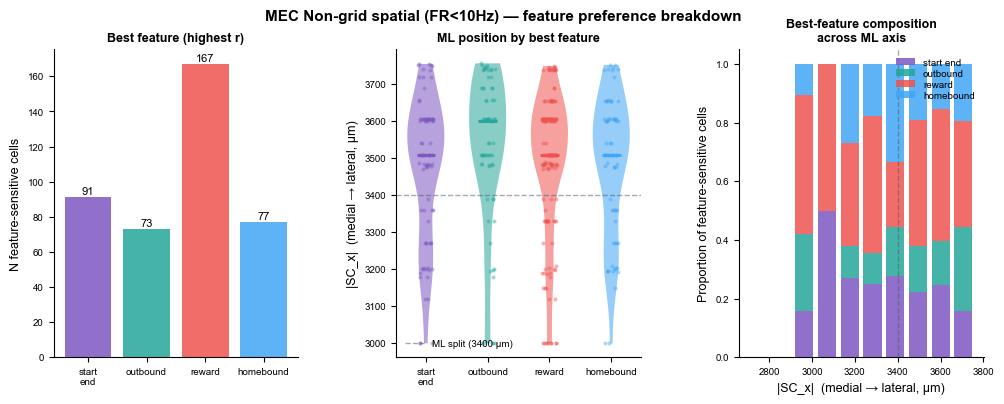

In [71]:
# Merge population results with cell_classifications for |SC_x| and firing rate
df_class_all = pd.read_csv(CLASSIFICATIONS_CSV)[
    ['mouse','day','cluster_id','SC_x','cell_type','firing_rate_VR']
]
df_class_all['ml']    = df_class_all['SC_x'].abs()
df_class_all['mouse'] = df_class_all['mouse'].astype(int)
df_class_all['day']   = df_class_all['day'].astype(int)
df_pop['mouse']       = df_pop['mouse'].astype(int)
df_pop['day']         = df_pop['day'].astype(int)

df_merged_all = df_pop.merge(df_class_all, on=['mouse','day','cluster_id'], how='inner')

# ── MEC + principal cells only ────────────────────────────────────────────────
df_merged_all = df_merged_all[
    df_merged_all['brain_region'].str.startswith('ENTm', na=False) &
    (df_merged_all['firing_rate_VR'] < 10)
].copy()
df_merged_all['best_feature'] = df_merged_all[feat_names].idxmax(axis=1)

ML_SPLIT = 3400

print(f'MEC principal cells (ENTm*, FR<10Hz): {len(df_merged_all)}')
print(df_merged_all['cell_type'].value_counts().to_string())

# ── Loop over cell-type subsets ───────────────────────────────────────────────
CELL_TYPE_GROUPS = [
    ('all',  'All MEC principal',  df_merged_all),
    ('GC',   'Grid cells (GC)',    df_merged_all[df_merged_all['cell_type'] == 'GC']),
    ('NGS',  'Non-grid spatial',   df_merged_all[df_merged_all['cell_type'] == 'NG']),
]

for ct_key, ct_label, df in CELL_TYPE_GROUPS:
    if len(df) == 0:
        print(f'No cells for {ct_label} — skipping')
        continue

    sig_pop  = df[df['eta2_sig']].copy()
    nsig_pop = df[~df['eta2_sig']].copy()
    medial_e  = df[df['ml'] <= ML_SPLIT]['eta2'].dropna()
    lateral_e = df[df['ml'] >  ML_SPLIT]['eta2'].dropna()

    rho, rho_p   = spearmanr(df['ml'], df['eta2'])
    mwu_u, mwu_p = mannwhitneyu(sig_pop['ml'], nsig_pop['ml'], alternative='two-sided') \
                   if len(sig_pop) > 0 and len(nsig_pop) > 0 else (np.nan, np.nan)
    _, mwu2_p    = mannwhitneyu(medial_e, lateral_e, alternative='two-sided') \
                   if len(medial_e) > 1 and len(lateral_e) > 1 else (np.nan, np.nan)

    print(f'\n── {ct_label}  (n={len(df)}, sig={len(sig_pop)}) ──')
    print(f'  Spearman r(ML,η²): ρ={rho:.3f}  p={rho_p:.4f}')
    print(f'  MW η² med vs lat:  p={mwu2_p:.4f}')
    if len(sig_pop) > 0:
        print('  Best feature counts:')
        print(sig_pop['best_feature'].value_counts().to_string())

    unique_regions = sorted(df['brain_region'].dropna().unique())
    reg_col = dict(zip(unique_regions,
                       plt.cm.tab10(np.linspace(0, 0.9, len(unique_regions)))))

    # ── Figure 1: ML gradient (2×2) ──────────────────────────────────────────
    fig, axes = plt.subplots(2, 2, figsize=(11, 8),
                             gridspec_kw=dict(hspace=0.42, wspace=0.38))

    # A: ML vs η² scatter
    ax = axes[0, 0]
    for region in unique_regions:
        sub = df[df['brain_region'] == region]
        ax.scatter(sub['ml'], sub['eta2'], s=6, color=reg_col[region],
                   alpha=0.25, lw=0, label=region)
    if len(sig_pop) > 0:
        ax.scatter(sig_pop['ml'], sig_pop['eta2'], s=18, facecolors='none',
                   edgecolors='#E53935', lw=0.7, zorder=5, label='feature-sensitive')
    ml_s = np.sort(df['ml'].values)
    ax.plot(ml_s, np.polyval(np.polyfit(df['ml'], df['eta2'], 1), ml_s),
            color='#37474F', lw=1.2, ls='--', alpha=0.7)
    ax.axhline(df['eta2_null_95'].mean(), color='#B0BEC5', lw=0.9, ls=':')
    ax.axvline(ML_SPLIT, color='#455A64', lw=1.0, ls='--', alpha=0.5,
               label=f'ML split ({ML_SPLIT} µm)')
    ax.set_xlabel('|SC_x|  (medial → lateral, µm)', fontsize=9)
    ax.set_ylabel('η²', fontsize=9)
    ax.set_title(f'ML vs feature sensitivity  (ρ={rho:.2f}, p={rho_p:.3f})',
                 fontsize=9, fontweight='bold')
    ax.spines[['top','right']].set_visible(False); ax.tick_params(labelsize=7)
    ax.legend(fontsize=6, frameon=False, markerscale=1.5, labelspacing=0.2)

    # B: fraction feature-sensitive per ML bin
    ax = axes[0, 1]
    ml_vals = df['ml'].values
    edges   = np.linspace(ml_vals.min(), ml_vals.max(), ML_BINS+1)
    ctrs    = (edges[:-1]+edges[1:])/2
    n_all   = np.array([np.sum((ml_vals>=e0)&(ml_vals<e1))
                        for e0,e1 in zip(edges[:-1],edges[1:])])
    n_sig_b = np.array([np.sum((sig_pop['ml'].values>=e0)&(sig_pop['ml'].values<e1))
                        for e0,e1 in zip(edges[:-1],edges[1:])]) if len(sig_pop)>0 \
              else np.zeros(ML_BINS)
    frac = np.where(n_all>0, n_sig_b/n_all, np.nan)
    sem  = np.where(n_all>0, np.sqrt(frac*(1-frac)/np.where(n_all>0,n_all,1)), np.nan)
    ax.bar(ctrs, frac, width=np.diff(edges)*0.8, color='#E53935', alpha=0.65, lw=0)
    ax.errorbar(ctrs, frac, yerr=sem, fmt='none', color='#B71C1C', lw=1.1, capsize=3)
    ax.axvline(ML_SPLIT, color='#455A64', lw=1.0, ls='--', alpha=0.5)
    axb = ax.twinx()
    axb.step(edges, np.append(n_all,n_all[-1]), color='#90A4AE', lw=0.9, where='post', alpha=0.6)
    axb.set_ylabel('N cells', fontsize=7, color='#90A4AE')
    axb.tick_params(labelsize=6, labelcolor='#90A4AE')
    axb.spines[['top','left']].set_visible(False)
    ax.set_xlabel('|SC_x|  (medial → lateral, µm)', fontsize=9)
    ax.set_ylabel('Fraction feature-sensitive', fontsize=9)
    ax.set_title('Feature sensitivity across ML axis', fontsize=9, fontweight='bold')
    ax.set_ylim(0, min(1.05, np.nanmax(frac)+0.15) if np.any(np.isfinite(frac)) else 1.05)
    ax.spines[['top','right']].set_visible(False); ax.tick_params(labelsize=7)

    # C: η² distribution medial vs lateral
    ax = axes[1, 0]
    bins_e = np.linspace(0, df['eta2'].max(), 35)
    ax.hist(medial_e,  bins=bins_e, color='#5C6BC0', alpha=0.70, density=True,
            edgecolor='none', label=f'Medial  ≤{ML_SPLIT} µm  (n={len(medial_e)})')
    ax.hist(lateral_e, bins=bins_e, color='#EF5350', alpha=0.70, density=True,
            edgecolor='none', label=f'Lateral >{ML_SPLIT} µm  (n={len(lateral_e)})')
    ax.set_xlabel('η²', fontsize=9)
    ax.set_ylabel('Density', fontsize=9)
    ax.set_title(f'η²: medial vs lateral\nMann-Whitney p={mwu2_p:.4f}',
                 fontsize=9, fontweight='bold')
    ax.legend(fontsize=7.5, frameon=False)
    ax.spines[['top','right']].set_visible(False); ax.tick_params(labelsize=7)

    # D: per-mouse fraction sig — medial vs lateral
    ax = axes[1, 1]
    mice = sorted(df['mouse'].unique())
    x_med, x_lat = [], []
    for mouse in mice:
        sub = df[df['mouse'] == mouse]
        med = sub[sub['ml'] <= ML_SPLIT]
        lat = sub[sub['ml'] >  ML_SPLIT]
        x_med.append(med['eta2_sig'].mean() if len(med) > 0 else np.nan)
        x_lat.append(lat['eta2_sig'].mean() if len(lat) > 0 else np.nan)
    x = np.arange(len(mice)); w = 0.35
    ax.bar(x-w/2, x_med, w, color='#5C6BC0', alpha=0.80, lw=0, label=f'Medial ≤{ML_SPLIT}')
    ax.bar(x+w/2, x_lat, w, color='#EF5350', alpha=0.80, lw=0, label=f'Lateral >{ML_SPLIT}')
    for xi, fm, fl in zip(x, x_med, x_lat):
        if np.isfinite(fm) and np.isfinite(fl):
            ax.plot([xi-w/2, xi+w/2], [fm, fl], color='k', lw=0.8, alpha=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels([f'M{m}' for m in mice], fontsize=7)
    ax.set_ylabel('Fraction feature-sensitive', fontsize=9)
    ax.set_title('Per-mouse: medial vs lateral', fontsize=9, fontweight='bold')
    ax.legend(fontsize=7.5, frameon=False)
    ax.spines[['top','right']].set_visible(False); ax.tick_params(labelsize=7)

    fig.suptitle(f'MEC {ct_label} (FR<10Hz) — ML gradient in feature sensitivity',
                 fontsize=11, fontweight='bold')
    plt.savefig(f'population_eta2_ML_{ct_key}.pdf', bbox_inches='tight', dpi=150)
    plt.show()

    # ── Figure 2: best-feature breakdown ─────────────────────────────────────
    if len(sig_pop) == 0:
        print(f'  No significant cells for {ct_label} — skipping feature breakdown')
        continue

    fig2, axes2 = plt.subplots(1, 3, figsize=(12, 4.0),
                                gridspec_kw=dict(wspace=0.40))

    # A: counts per best feature
    ax = axes2[0]
    counts = sig_pop['best_feature'].value_counts().reindex(feat_names, fill_value=0)
    bars = ax.bar(range(len(feat_names)), counts.values,
                  color=[FEATURE_COLOURS[f] for f in feat_names], alpha=0.85, lw=0)
    ax.set_xticks(range(len(feat_names)))
    ax.set_xticklabels([f.replace('_','\n') for f in feat_names], fontsize=8)
    ax.set_ylabel('N feature-sensitive cells', fontsize=9)
    ax.set_title('Best feature (highest r)', fontsize=9, fontweight='bold')
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                str(val), ha='center', va='bottom', fontsize=8)
    ax.spines[['top','right']].set_visible(False); ax.tick_params(labelsize=7)

    # B: ML per best feature — violin + strip
    ax = axes2[1]
    for fi, fname in enumerate(feat_names):
        sub = sig_pop[sig_pop['best_feature'] == fname]['ml']
        if len(sub) == 0:
            continue
        parts = ax.violinplot(sub, positions=[fi], widths=0.6,
                              showmedians=True, showextrema=False)
        for pc in parts['bodies']:
            pc.set_facecolor(FEATURE_COLOURS[fname]); pc.set_alpha(0.55)
        parts['cmedians'].set_color(FEATURE_COLOURS[fname])
        parts['cmedians'].set_linewidth(2)
        jitter = np.random.default_rng(fi).uniform(-0.12, 0.12, len(sub))
        ax.scatter(fi + jitter, sub, s=8, color=FEATURE_COLOURS[fname],
                   alpha=0.45, lw=0, zorder=3)
    ax.axhline(ML_SPLIT, color='#455A64', lw=1.0, ls='--', alpha=0.5,
               label=f'ML split ({ML_SPLIT} µm)')
    ax.set_xticks(range(len(feat_names)))
    ax.set_xticklabels([f.replace('_','\n') for f in feat_names], fontsize=8)
    ax.set_ylabel('|SC_x|  (medial → lateral, µm)', fontsize=9)
    ax.set_title('ML position by best feature', fontsize=9, fontweight='bold')
    ax.legend(fontsize=7, frameon=False)
    ax.spines[['top','right']].set_visible(False); ax.tick_params(labelsize=7)

    # C: stacked proportions per ML bin
    ax = axes2[2]
    bottom = np.zeros(ML_BINS)
    for fname in feat_names:
        sub_ml = sig_pop[sig_pop['best_feature'] == fname]['ml'].values
        n_feat = np.array([np.sum((sub_ml>=e0)&(sub_ml<e1))
                           for e0,e1 in zip(edges[:-1],edges[1:])])
        prop = np.where(n_sig_b>0, n_feat/n_sig_b, 0.0)
        ax.bar(ctrs, prop, width=np.diff(edges)*0.8, bottom=bottom,
               color=FEATURE_COLOURS[fname], alpha=0.85, lw=0,
               label=fname.replace('_',' '))
        bottom += prop
    ax.axvline(ML_SPLIT, color='#455A64', lw=1.0, ls='--', alpha=0.5)
    ax.set_xlabel('|SC_x|  (medial → lateral, µm)', fontsize=9)
    ax.set_ylabel('Proportion of feature-sensitive cells', fontsize=9)
    ax.set_title('Best-feature composition\nacross ML axis', fontsize=9, fontweight='bold')
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=7, frameon=False, loc='upper right', labelspacing=0.2)
    ax.spines[['top','right']].set_visible(False); ax.tick_params(labelsize=7)

    fig2.suptitle(f'MEC {ct_label} (FR<10Hz) — feature preference breakdown',
                  fontsize=11, fontweight='bold')
    plt.savefig(f'population_best_feature_{ct_key}.pdf', bbox_inches='tight', dpi=150)
    plt.show()